In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import hdbscan
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import cdist

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


In [3]:
from google.colab import files
uploaded = files.upload()

Saving olist_cleaned_dataset.csv to olist_cleaned_dataset.csv


In [4]:
df = pd.read_csv(next(iter(uploaded)))
print(f"\nDataset Shape: {df.shape}")
print(f"Number of Customers: {len(df)}")
print("\nFirst few rows:")
print(df.head())


Dataset Shape: (93358, 33)
Number of Customers: 93358

First few rows:
                 customer_unique_id  num_orders  total_spent  avg_order_value  \
0  0000366f3b9a7992bf8c76cfdf3221e2   -0.159829    -0.015717         0.003713   
1  0000b849f77a49e4a4ce2b2a4ca5be3f   -0.159829    -0.574829        -0.570550   
2  0000f46a3911fa3c0805444483337064   -0.159829    -0.322473        -0.311356   
3  0000f6ccb0745a6a4b88665a16c9f078   -0.159829    -0.539117        -0.533870   
4  0004aac84e0df4da2b147fca70cf8255   -0.159829     0.236639         0.262908   

   avg_item_price_per_order  avg_items_per_order  avg_review  \
0                  0.021035            -0.172165    0.663285   
1                 -0.561497            -0.172165   -0.120408   
2                 -0.298570            -0.172165   -0.904101   
3                 -0.524289            -0.172165   -0.120408   
4                  0.283963            -0.172165    0.663285   

   avg_installments      city state  ...  cat_pca_1  cat

In [5]:
print("\nData Types:")
print(df.dtypes)


Data Types:
customer_unique_id                object
num_orders                       float64
total_spent                      float64
avg_order_value                  float64
avg_item_price_per_order         float64
avg_items_per_order              float64
avg_review                       float64
avg_installments                 float64
city                              object
state                             object
latitude                         float64
longitude                        float64
recency_days                     float64
num_product_categories           float64
most_bought_category              object
least_bought_category             object
least_used_payment                object
aov_range                         object
avg_item_price_range              object
most_used_payment_boleto         float64
most_used_payment_credit_card    float64
most_used_payment_debit_card     float64
most_used_payment_voucher        float64
cat_pca_1                        float64
cat

In [6]:
numerical_features = [
    'num_orders', 'total_spent', 'avg_order_value', 'avg_item_price_per_order',
    'avg_items_per_order', 'avg_review', 'avg_installments',
    'recency_days', 'num_product_categories',
    'cat_pca_1', 'cat_pca_2', 'cat_pca_3', 'cat_pca_4', 'cat_pca_5',
    'cat_pca_6', 'cat_pca_7', 'cat_pca_8', 'cat_pca_9', 'cat_pca_10'
]


In [7]:
X = df[numerical_features].copy()

print(f"\nFeature Matrix Shape: {X.shape}")
print(f"Features used: {len(numerical_features)}")
print("\nFeature Statistics:")
print(X.describe())


Feature Matrix Shape: (93358, 19)
Features used: 19

Feature Statistics:
         num_orders   total_spent  avg_order_value  avg_item_price_per_order  \
count  9.335800e+04  9.335800e+04     9.335800e+04              9.335800e+04   
mean  -4.734009e-17 -1.164475e-16     8.098047e-17              1.064010e-16   
std    1.000005e+00  1.000005e+00     1.000005e+00              1.000005e+00   
min   -1.598294e-01 -6.657481e-01    -6.639326e-01             -6.562247e-01   
25%   -1.598294e-01 -4.438662e-01    -4.381074e-01             -4.355444e-01   
50%   -1.598294e-01 -2.524584e-01    -2.545501e-01             -2.460900e-01   
75%   -1.598294e-01  8.049047e-02     8.131638e-02              7.351594e-02   
max    6.679496e+01  3.654368e+01     3.417549e+01              3.468489e+01   

       avg_items_per_order    avg_review  avg_installments  recency_days  \
count         9.335800e+04  9.335800e+04      9.335800e+04  9.335800e+04   
mean         -5.700409e-16  1.703615e-16      2.38222

Standardization


In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features standardized successfully!")
print(f"Mean after scaling: {X_scaled.mean():.10f}")
print(f"Std after scaling: {X_scaled.std():.6f}")

Features standardized successfully!
Mean after scaling: 0.0000000000
Std after scaling: 1.000000


PCA

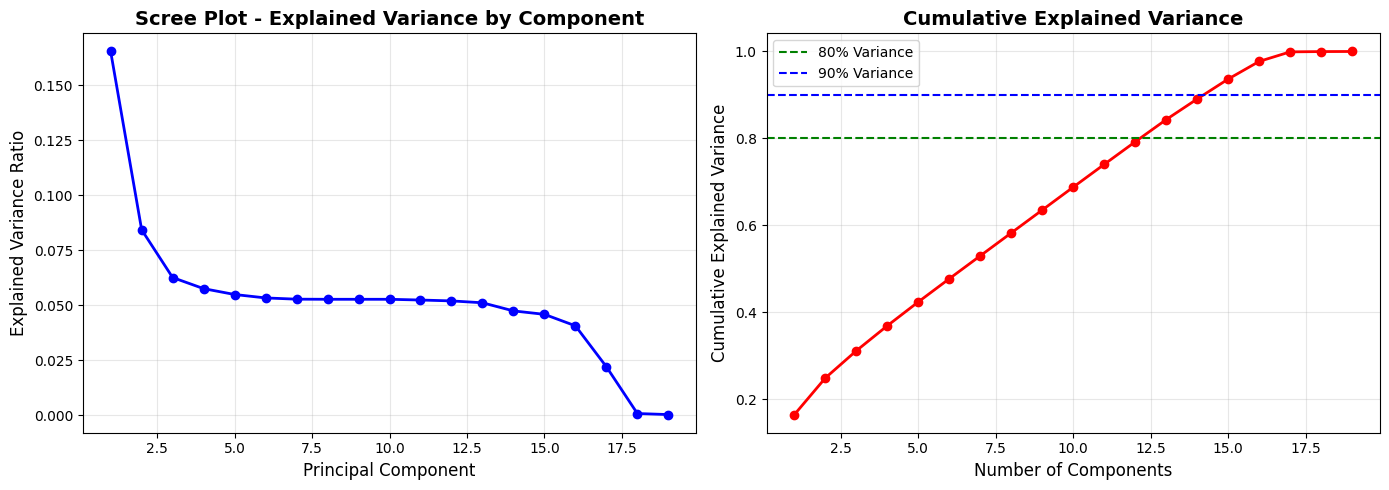


Components for 80% variance: 13
Components for 90% variance: 15

First 10 components explain: 0.6882 (68.82%) of variance

Using 13 components for clustering

PCA Transformed Shape: (93358, 13)
Variance explained by selected components: 0.8435

2D PCA variance explained: 0.2496
3D PCA variance explained: 0.3121


In [9]:
pca_full = PCA()
pca_full.fit(X_scaled)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(14, 5))

# Scree plot
plt.subplot(1, 2, 1)
plt.plot(range(1, len(explained_variance) + 1), explained_variance, 'bo-', linewidth=2)
plt.xlabel('Principal Component', fontsize=12)
plt.ylabel('Explained Variance Ratio', fontsize=12)
plt.title('Scree Plot - Explained Variance by Component', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Cumulative variance
plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'ro-', linewidth=2)
plt.axhline(y=0.80, color='g', linestyle='--', label='80% Variance')
plt.axhline(y=0.90, color='b', linestyle='--', label='90% Variance')
plt.xlabel('Number of Components', fontsize=12)
plt.ylabel('Cumulative Explained Variance', fontsize=12)
plt.title('Cumulative Explained Variance', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#optimal number of components for 80% and 90% variance
n_components_80 = np.argmax(cumulative_variance >= 0.80) + 1
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1

print(f"\nComponents for 80% variance: {n_components_80}")
print(f"Components for 90% variance: {n_components_90}")
print(f"\nFirst 10 components explain: {cumulative_variance[9]:.4f} ({cumulative_variance[9]*100:.2f}%) of variance")

# Choose optimal number of components (use 80% threshold)
n_components_optimal = n_components_80
print(f"\nUsing {n_components_optimal} components for clustering")

# Apply PCA with optimal components
pca = PCA(n_components=n_components_optimal)
X_pca = pca.fit_transform(X_scaled)

print(f"\nPCA Transformed Shape: {X_pca.shape}")
print(f"Variance explained by selected components: {pca.explained_variance_ratio_.sum():.4f}")

# For visualization, also create 2D and 3D versions
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

print(f"\n2D PCA variance explained: {pca_2d.explained_variance_ratio_.sum():.4f}")
print(f"3D PCA variance explained: {pca_3d.explained_variance_ratio_.sum():.4f}")

K means clustering

K=2: Inertia=1333586.38, Silhouette=0.4477
K=3: Inertia=1248514.70, Silhouette=0.1297
K=4: Inertia=1156570.87, Silhouette=0.0827
K=5: Inertia=1072611.68, Silhouette=0.1334
K=6: Inertia=999584.93, Silhouette=0.1433
K=7: Inertia=922247.02, Silhouette=0.2089
K=8: Inertia=844504.40, Silhouette=0.2404
K=9: Inertia=776405.15, Silhouette=0.2601
K=10: Inertia=708701.81, Silhouette=0.2953


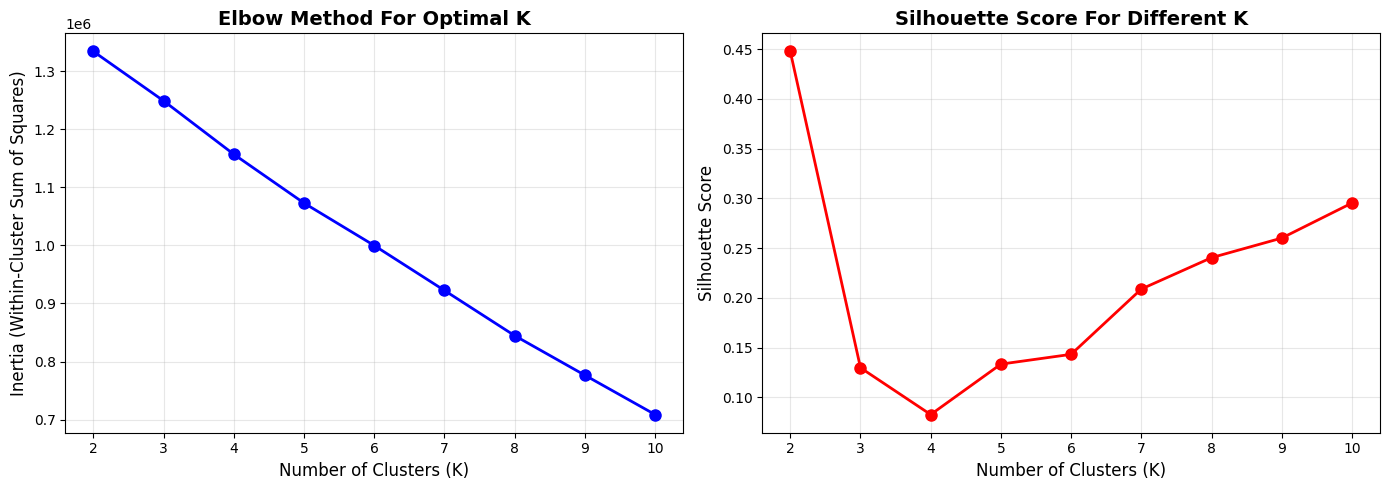


Optimal K based on Silhouette Score: 2

Fitting K-Means with K=2...

K-Means Results (K=2):
  Silhouette Score: 0.4477
  Davies-Bouldin Index: 1.1552 (lower is better)
  Calinski-Harabasz Index: 11381.97 (higher is better)
  Inertia: 1333586.38


In [13]:
clustering_results = {}
evaluation_metrics = []
inertias = []
silhouette_scores = []
k_range = range(2, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42, max_iter=300)
    kmeans.fit(X_pca)
    inertias.append(kmeans.inertia_)
    sil_score = silhouette_score(X_pca, kmeans.labels_)
    silhouette_scores.append(sil_score)
    print(f"K={k}: Inertia={kmeans.inertia_:.2f}, Silhouette={sil_score:.4f}")

# Plot Elbow and Silhouette
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Elbow plot
axes[0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[0].set_ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
axes[0].set_title('Elbow Method For Optimal K', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Silhouette plot
axes[1].plot(k_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score For Different K', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

optimal_k = k_range[np.argmax(silhouette_scores)]
print(f"\nOptimal K based on Silhouette Score: {optimal_k}")

print(f"\nFitting K-Means with K={optimal_k}...")
kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', n_init=10, random_state=42, max_iter=300)
kmeans_labels = kmeans_final.fit_predict(X_pca)

# Evaluate
kmeans_silhouette = silhouette_score(X_pca, kmeans_labels)
kmeans_db = davies_bouldin_score(X_pca, kmeans_labels)
kmeans_ch = calinski_harabasz_score(X_pca, kmeans_labels)

clustering_results['kmeans'] = kmeans_labels

evaluation_metrics.append({
    'Model': 'K-Means',
    'N_Clusters': optimal_k,
    'Silhouette': kmeans_silhouette,
    'Davies-Bouldin': kmeans_db,
    'Calinski-Harabasz': kmeans_ch,
    'Inertia': kmeans_final.inertia_
})

print(f"\nK-Means Results (K={optimal_k}):")
print(f"  Silhouette Score: {kmeans_silhouette:.4f}")
print(f"  Davies-Bouldin Index: {kmeans_db:.4f} (lower is better)")
print(f"  Calinski-Harabasz Index: {kmeans_ch:.2f} (higher is better)")
print(f"  Inertia: {kmeans_final.inertia_:.2f}")

In [14]:
df['kmeans_cluster'] = kmeans_labels


In [15]:
cluster_profile = df.groupby('kmeans_cluster').agg({
    'num_orders':'mean',
    'total_spent':'mean',
    'avg_order_value':'mean',
    'recency_days':'mean',
    'avg_review':'mean',
    'avg_items_per_order':'mean',
    'avg_installments':'mean',
}).round(2)

cluster_profile['customers'] = df.groupby('kmeans_cluster').size()
cluster_profile['customers_%'] = (cluster_profile['customers'] / len(df) * 100).round(2)

print(cluster_profile)



                num_orders  total_spent  avg_order_value  recency_days  \
kmeans_cluster                                                           
0                     0.00        -0.14            -0.14          -0.0   
1                    -0.02         3.98             4.02           0.0   

                avg_review  avg_items_per_order  avg_installments  customers  \
kmeans_cluster                                                                 
0                     0.00                -0.00             -0.05      90223   
1                    -0.05                 0.02              1.34       3135   

                customers_%  
kmeans_cluster               
0                     96.64  
1                      3.36  


In [18]:
cluster_names = {
    0: "High-Value Loyal Customers",
    1: "Price-Sensitive Frequent Buyers",
    2: "New or Low-Engaged Customers",
    3: "At-Risk Customers / Churn Group"
}

df['segment'] = df['kmeans_cluster'].map(cluster_names)


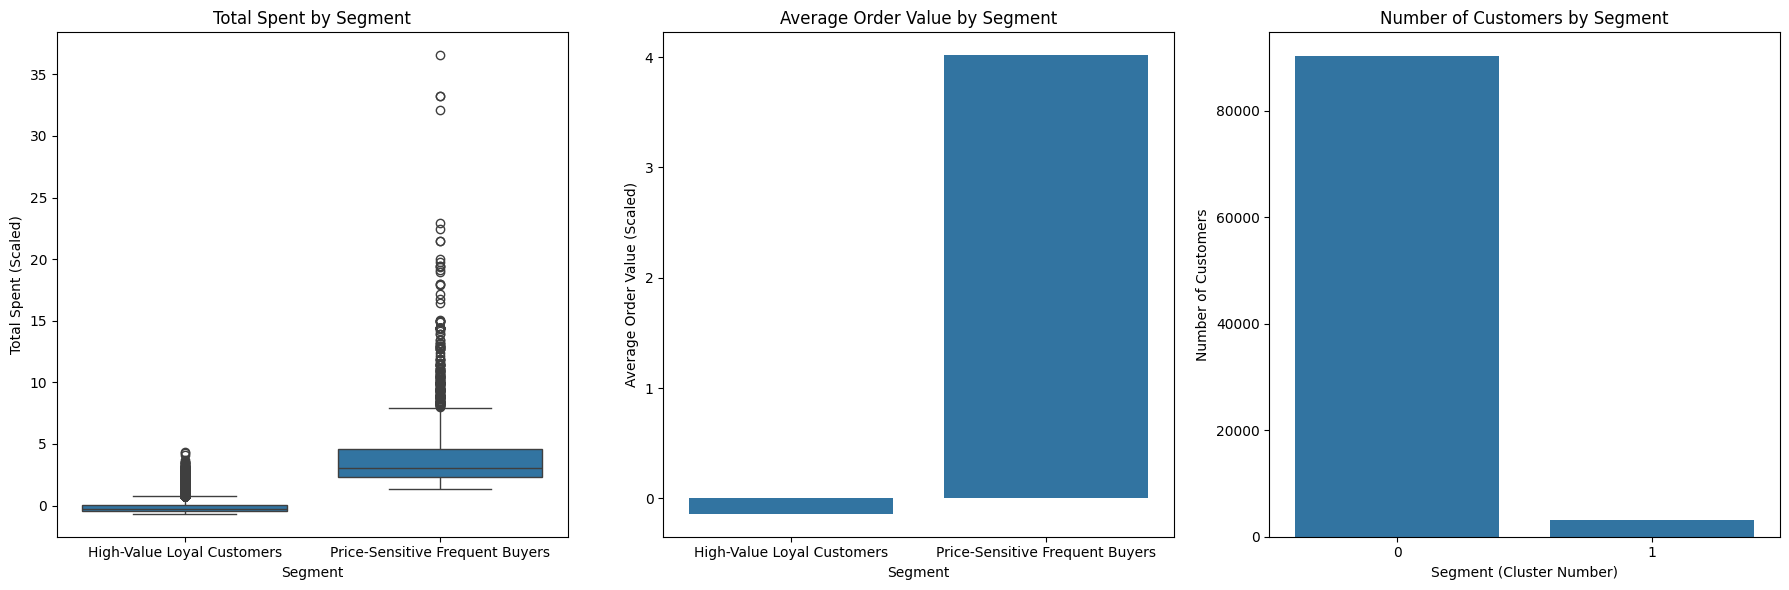

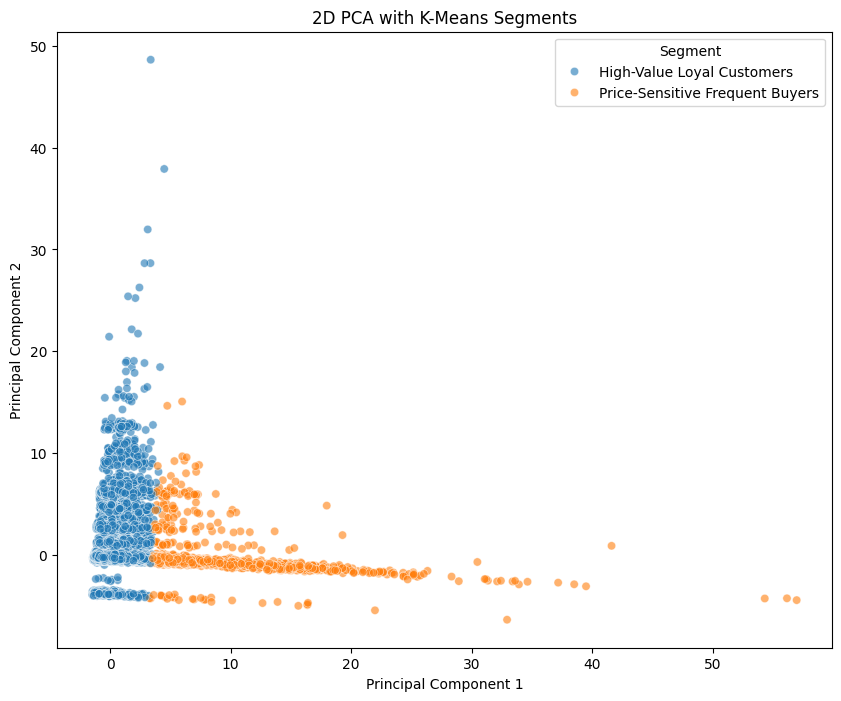

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt # Import matplotlib

# Create a figure and axes for the plots
fig, axes = plt.subplots(1, 3, figsize=(18, 6)) # Adjust figsize as needed

# Boxplot of total_spent per segment
sns.boxplot(x='segment', y='total_spent', data=df, ax=axes[0])
axes[0].set_title('Total Spent by Segment')
axes[0].set_xlabel('Segment')
axes[0].set_ylabel('Total Spent (Scaled)')

# Barplot of avg_order_value per segment
sns.barplot(x='segment', y='avg_order_value', data=df.groupby('segment')['avg_order_value'].mean().reset_index(), ax=axes[1]) # Calculate mean before plotting
axes[1].set_title('Average Order Value by Segment')
axes[1].set_xlabel('Segment')
axes[1].set_ylabel('Average Order Value (Scaled)')

# Barplot of customer count per segment (using cluster_profile)
sns.barplot(x='kmeans_cluster', y='customers', data=cluster_profile.reset_index(), ax=axes[2]) # Use 'kmeans_cluster' for the x-axis
axes[2].set_title('Number of Customers by Segment')
axes[2].set_xlabel('Segment (Cluster Number)')
axes[2].set_ylabel('Number of Customers')

plt.tight_layout()
plt.show()


# Scatterplot of 2D PCA with segments (optional, can be in a separate cell if preferred)
plt.figure(figsize=(10, 8))
sns.scatterplot(x=X_pca_2d[:,0], y=X_pca_2d[:,1], hue=df['segment'], alpha=0.6)
plt.title('2D PCA with K-Means Segments')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Segment')
plt.show()

DBSCAN


In [21]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

dbscan = DBSCAN(eps=0.6, min_samples=50)
dbscan_labels = dbscan.fit_predict(X_pca)

# Count clusters (DBSCAN labels noise points as -1)
n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)

print(f"DBSCAN found {n_clusters_dbscan} clusters")
print(f"Noise points: {(dbscan_labels == -1).sum()}")


DBSCAN found 48 clusters
Noise points: 23788


In [22]:
if n_clusters_dbscan > 1:
    dbscan_silhouette = silhouette_score(X_pca, dbscan_labels)
    dbscan_db = davies_bouldin_score(X_pca, dbscan_labels)
    dbscan_ch = calinski_harabasz_score(X_pca, dbscan_labels)

    print(f"Silhouette Score: {dbscan_silhouette:.4f}")
    print(f"Davies-Bouldin Index: {dbscan_db:.4f}")
    print(f"Calinski-Harabasz Score: {dbscan_ch:.2f}")

    evaluation_metrics.append({
        'Model': 'DBSCAN',
        'N_Clusters': n_clusters_dbscan,
        'Silhouette': dbscan_silhouette,
        'Davies-Bouldin': dbscan_db,
        'Calinski-Harabasz': dbscan_ch,
        'Inertia': None
    })
else:
    print("DBSCAN did not form enough clusters — adjust eps/min_samples")


Silhouette Score: 0.1783
Davies-Bouldin Index: 1.4752
Calinski-Harabasz Score: 2204.69


In [23]:
df['dbscan_cluster'] = dbscan_labels
clustering_results['dbscan'] = dbscan_labels

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


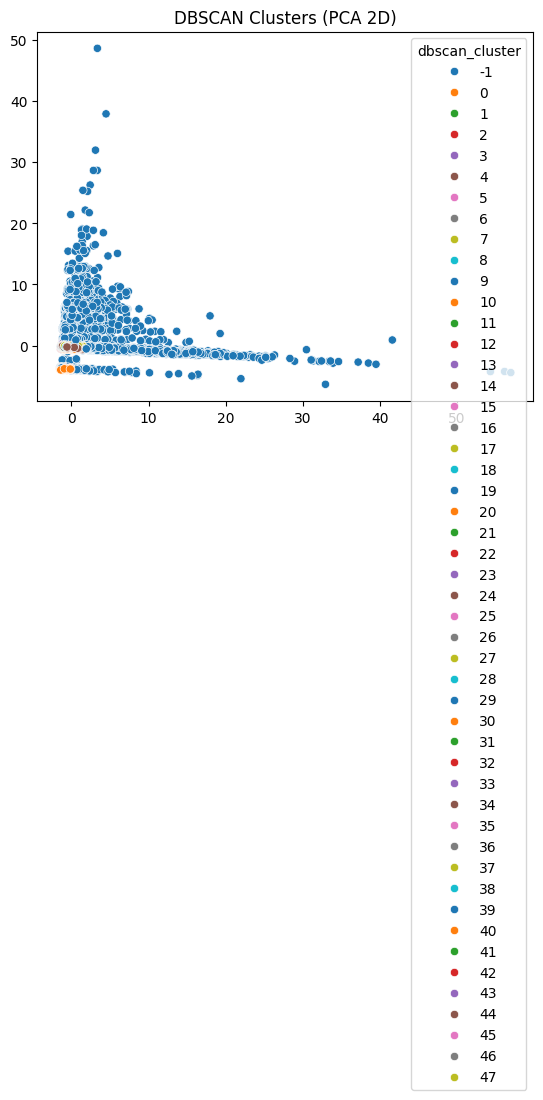

In [24]:
sns.scatterplot(x=X_pca_2d[:, 0], y=X_pca_2d[:, 1], hue=df['dbscan_cluster'], palette='tab10')
plt.title("DBSCAN Clusters (PCA 2D)")
plt.show()

In [25]:
for eps in [0.2, 0.3, 0.4, 0.5]:
    db = DBSCAN(eps=eps, min_samples=50)
    labels = db.fit_predict(X_pca)
    n_clust = len(set(labels)) - (1 if -1 in labels else 0)
    noise = list(labels).count(-1)
    print(f"eps={eps} → clusters={n_clust}, noise={noise}")



eps=0.2 → clusters=45, noise=71248
eps=0.3 → clusters=62, noise=52218
eps=0.4 → clusters=77, noise=39061
eps=0.5 → clusters=94, noise=30703
